# Character Recognition CNN - EMNIST `balanced`

Small CNN trained on EMNIST `balanced` (47 classes: digits, uppercase, and 11 lowercase letters that don't look like their uppercase form). Hyperparameters tuned with Optuna.

Weights are saved to `../models/recognition_cnn.pt` and loaded by `../main.py`.

In [54]:
import copy
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import transforms
from torchvision.datasets import EMNIST
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import optuna
from optuna.pruners import MedianPruner
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Device

In [55]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


## Paths

`MODELS_DIR` is shared with the denoising stage.

In [56]:
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / "data"
MODELS_DIR = NOTEBOOK_DIR.parent / "models"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR  :", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)

DATA_DIR  : /Users/suryaguthikonda/Personal/Github/crisp/stage1_ocr/recognition/data
MODELS_DIR: /Users/suryaguthikonda/Personal/Github/crisp/stage1_ocr/models


## Label map

`LABEL_MAP[i]` -> printable character for class `i`. Order matches `torchvision`'s EMNIST `balanced`: digits, uppercase, then 11 unmerged lowercase letters.

In [57]:
import string

_MERGED_LOWERCASE = {"c", "i", "j", "k", "l", "m", "o", "p", "s", "u", "v", "w", "x", "y", "z"}
_ALL_CLASSES = set(string.digits + string.ascii_letters)
LABEL_MAP = sorted(_ALL_CLASSES - _MERGED_LOWERCASE)
NUM_CLASSES = len(LABEL_MAP)
assert NUM_CLASSES == 47

print(f"NUM_CLASSES: {NUM_CLASSES}")
print("First 15 classes :", LABEL_MAP[:15])
print("Last  15 classes :", LABEL_MAP[-15:])

NUM_CLASSES: 47
First 15 classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E']
Last  15 classes : ['W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']


## Preprocessing

EMNIST images are stored rotated/flipped, so we transpose them first. `build_transforms` is shared with inference code; `augment=True` adds a small affine jitter for training.

In [58]:
IMG_SIZE = 28
EMNIST_MEAN = (0.1307,)
EMNIST_STD = (0.3081,)


def _fix_emnist_orientation(img: Image.Image) -> Image.Image:
    return img.transpose(Image.TRANSPOSE)


def build_transforms(augment: bool) -> transforms.Compose:
    steps = [transforms.Lambda(_fix_emnist_orientation)]
    if augment:
        steps.append(
            transforms.RandomAffine(
                degrees=10, translate=(0.08, 0.08), scale=(0.9, 1.1), fill=0
            )
        )
    steps.extend(
        [
            transforms.ToTensor(),
            transforms.Normalize(EMNIST_MEAN, EMNIST_STD),
        ]
    )
    return transforms.Compose(steps)


train_transform = build_transforms(augment=True)
eval_transform = build_transforms(augment=False)

## Load EMNIST

Two views of the train set so validation examples never get augmented.

In [59]:
full_train_aug = EMNIST(
    root=str(DATA_DIR), split="balanced", train=True, download=True,
    transform=train_transform,
)
full_train_eval = EMNIST(
    root=str(DATA_DIR), split="balanced", train=True, download=True,
    transform=eval_transform,
)
test_set = EMNIST(
    root=str(DATA_DIR), split="balanced", train=False, download=True,
    transform=eval_transform,
)

assert list(full_train_aug.classes) == LABEL_MAP, (
    "torchvision's EMNIST `balanced` class order must match LABEL_MAP"
)

print(f"Full train: {len(full_train_aug):,}")
print(f"Test      : {len(test_set):,}")
print(f"Classes   : {NUM_CLASSES}")

Full train: 112,800
Test      : 18,800
Classes   : 47


## Train / val split

10% of train set, fixed seed. Test set untouched.

In [60]:
VAL_FRACTION = 0.1

n_total = len(full_train_aug)
n_val = int(round(n_total * VAL_FRACTION))
n_train = n_total - n_val

gen = torch.Generator().manual_seed(SEED)
train_subset_aug, val_subset_aug = random_split(
    full_train_aug, [n_train, n_val], generator=gen
)

val_subset = Subset(full_train_eval, val_subset_aug.indices)
train_subset = train_subset_aug

print(f"Train: {len(train_subset):,}")
print(f"Valid: {len(val_subset):,}")
print(f"Test : {len(test_set):,}")

Train: 101,520
Valid: 11,280
Test : 18,800


## Sample visualization

One unaugmented example per class.

/var/folders/0q/0w4kfd2j1f368l33_qspsxfr0000gn/T/ipykernel_30145/274101979.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  train_targets = np.array(full_train_eval.targets)


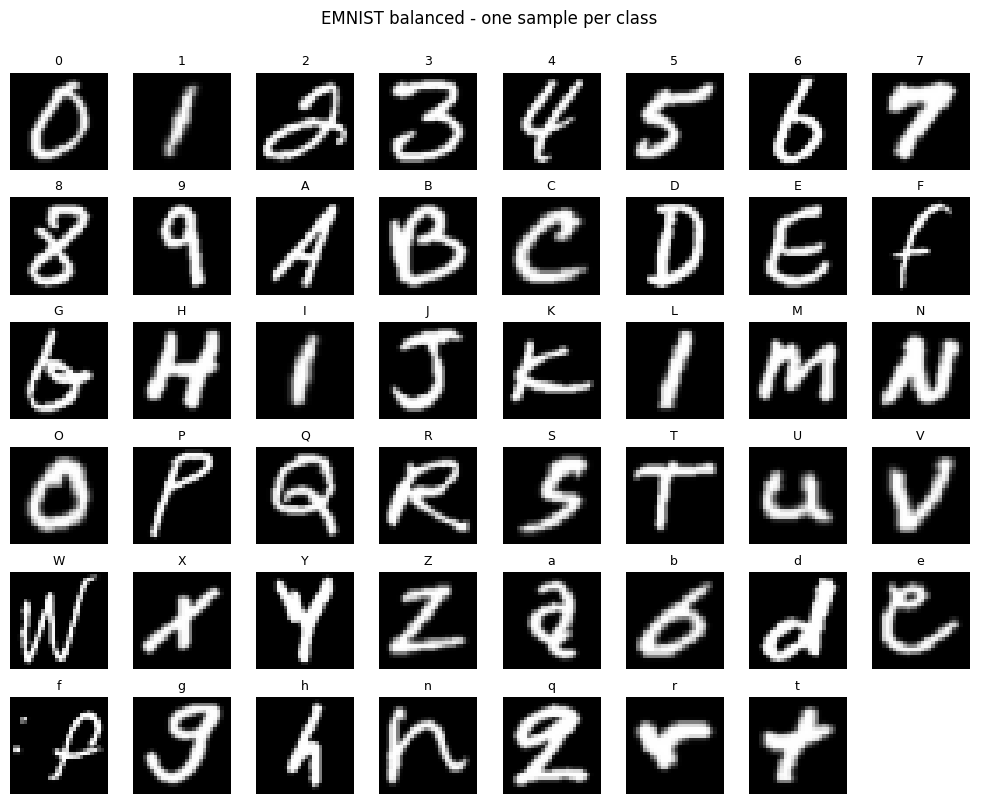

In [61]:
train_targets = np.array(full_train_eval.targets)
class_to_index: dict[int, int] = {}
for idx, y in enumerate(train_targets):
    y = int(y)
    if y not in class_to_index:
        class_to_index[y] = idx
        if len(class_to_index) == NUM_CLASSES:
            break

fig, axes = plt.subplots(6, 8, figsize=(10, 8))
axes = axes.flatten()
for cls in range(NUM_CLASSES):
    img, label = full_train_eval[class_to_index[cls]]
    axes[cls].imshow(img.squeeze().numpy(), cmap="gray")
    axes[cls].set_title(f"{LABEL_MAP[label]}", fontsize=9)
    axes[cls].axis("off")
for ax in axes[NUM_CLASSES:]:
    ax.axis("off")
plt.suptitle("EMNIST balanced - one sample per class", y=1.0)
plt.tight_layout()
plt.show()

## Class weights

The split is near-uniform so weights land near `1.0`, but we compute them anyway so the same loop works on the imbalanced EMNIST variants.

In [62]:
train_indices = np.array(train_subset_aug.indices)
train_labels = train_targets[train_indices]

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels,
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

print("Min weight:", float(class_weights.min()))
print("Max weight:", float(class_weights.max()))
print(
    "Rarest 5 classes:",
    [(LABEL_MAP[i], round(float(class_weights[i]), 2))
     for i in np.argsort(-class_weights_np)[:5]],
)

Min weight: 0.9809264540672302
Max weight: 1.0112359523773193
Rarest 5 classes: [('7', 1.01), ('K', 1.01), ('6', 1.01), ('P', 1.01), ('I', 1.01)]


## CNN model

Two `Conv -> BN -> ReLU` blocks (each = 2 convs + max-pool) and a dropout MLP head. Channel widths and dropout are tunable so Optuna can search them. Input `(B, 1, 28, 28)` -> 14 -> 7.

In [63]:
class RecognitionCNN(nn.Module):
    def __init__(
        self,
        conv1_ch: int = 32,
        conv2_ch: int = 64,
        fc_dim: int = 128,
        dropout: float = 0.3,
        num_classes: int = NUM_CLASSES,
    ):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, conv1_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(conv1_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(conv1_ch, conv1_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(conv1_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(conv1_ch, conv2_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(conv2_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(conv2_ch, conv2_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(conv2_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(conv2_ch * 7 * 7, fc_dim, bias=False),
            nn.BatchNorm1d(fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


_demo = RecognitionCNN()
_n_params = sum(p.numel() for p in _demo.parameters())
print(f"Default RecognitionCNN parameter count: {_n_params:,}")
print(_demo)

Default RecognitionCNN parameter count: 472,911
RecognitionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13)

## Train / eval helpers

In [64]:
def build_optimizer(name: str, params, lr: float) -> torch.optim.Optimizer:
    if name == "adam":
        return torch.optim.Adam(params, lr=lr)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr)
    if name == "sgd_momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=True)
    raise ValueError(f"Unknown optimizer: {name}")


def build_scheduler(
    name: str, optimizer: torch.optim.Optimizer, total_epochs: int
) -> torch.optim.lr_scheduler.LRScheduler | None:
    if name == "none":
        return None
    if name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=total_epochs, eta_min=1e-6,
        )
    raise ValueError(f"Unknown scheduler: {name}")


def execute_trainstep(model, device, loader, loss_criterion, optimizer):
    model.train()
    losses = []
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_criterion(logits, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return float(np.mean(losses)), correct / total


@torch.no_grad()
def validate(model, device, loader, loss_criterion):
    model.eval()
    losses = []
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = loss_criterion(logits, labels)
        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return float(np.mean(losses)), correct / total


@torch.no_grad()
def evaluate_predictions(model, device, loader):
    model.eval()
    all_preds: list[np.ndarray] = []
    all_labels: list[np.ndarray] = []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)

## Optuna tuning

Search space: `lr`, `batch_size`, `optimizer`, `scheduler` (none/cosine), `dropout`, `label_smoothing`, `conv1_ch`, `conv2_ch`, `fc_dim`.

Each trial trains on a `TUNING_TRAIN_SIZE` subset for `TUNING_EPOCHS` epochs and is scored by val accuracy. `MedianPruner` kills bad trials early. Final retrain uses the full train set.

In [65]:
N_TRIALS = 20
TUNING_EPOCHS = 3
TUNING_TRAIN_SIZE = 25_000
NUM_WORKERS = 0
PIN_MEMORY = device.type == "mps"

_tuning_rng = np.random.default_rng(SEED)
_tuning_indices = _tuning_rng.choice(
    len(train_subset), size=min(TUNING_TRAIN_SIZE, len(train_subset)), replace=False,
)
tuning_train_subset = Subset(train_subset, _tuning_indices.tolist())
print(f"Tuning train set: {len(tuning_train_subset):,} (of {len(train_subset):,})")


def make_loaders(batch_size: int, tuning: bool):
    train_src = tuning_train_subset if tuning else train_subset
    train_loader = DataLoader(
        train_src, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_subset, batch_size=512, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader


def objective(trial: optuna.Trial) -> float:
    lr = trial.suggest_float("lr", 3e-4, 5e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    optimizer_name = trial.suggest_categorical(
        "optimizer", ["adam", "adamw", "sgd_momentum"]
    )
    scheduler_name = trial.suggest_categorical("scheduler", ["none", "cosine"])
    dropout = trial.suggest_float("dropout", 0.1, 0.6)
    label_smoothing = trial.suggest_categorical("label_smoothing", [0.0, 0.05, 0.1])
    conv1_ch = trial.suggest_categorical("conv1_ch", [16, 32, 48])
    conv2_ch = trial.suggest_categorical("conv2_ch", [32, 64, 96])
    fc_dim = trial.suggest_categorical("fc_dim", [128, 256])

    model = RecognitionCNN(
        conv1_ch=conv1_ch, conv2_ch=conv2_ch, fc_dim=fc_dim, dropout=dropout,
    ).to(device)
    optimizer = build_optimizer(optimizer_name, model.parameters(), lr)
    scheduler = build_scheduler(scheduler_name, optimizer, total_epochs=TUNING_EPOCHS)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights, label_smoothing=label_smoothing
    )

    train_loader, val_loader = make_loaders(batch_size, tuning=True)

    best_val_acc = 0.0
    for epoch in range(TUNING_EPOCHS):
        execute_trainstep(model, device, train_loader, criterion, optimizer)
        _, val_acc = validate(model, device, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()
        best_val_acc = max(best_val_acc, val_acc)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_acc

Tuning train set: 25,000 (of 101,520)


In [66]:
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = MedianPruner(n_warmup_steps=1)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBest trial:")
print(f"  val_acc: {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-04-18 11:56:12,474] A new study created in memory with name: no-name-c34f4913-a77c-4775-a92c-cb8069324b9d
  0%|          | 0/20 [00:00<?, ?it/s]/Users/suryaguthikonda/Personal/Github/crisp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Best trial: 0. Best value: 0.866135:   5%|▌         | 1/20 [00:32<10:20, 32.68s/it]

[I 2026-04-18 11:56:45,157] Trial 0 finished with value: 0.8661347517730497 and parameters: {'lr': 0.0020384156710475903, 'batch_size': 64, 'optimizer': 'adam', 'scheduler': 'none', 'dropout': 0.4540362888980227, 'label_smoothing': 0.05, 'conv1_ch': 16, 'conv2_ch': 64, 'fc_dim': 256}. Best is trial 0 with value: 0.8661347517730497.


Best trial: 0. Best value: 0.866135:  10%|█         | 2/20 [00:45<06:20, 21.14s/it]

[I 2026-04-18 11:56:58,221] Trial 1 finished with value: 0.8573581560283688 and parameters: {'lr': 0.0006124286716805667, 'batch_size': 256, 'optimizer': 'adam', 'scheduler': 'none', 'dropout': 0.40377242595071916, 'label_smoothing': 0.1, 'conv1_ch': 16, 'conv2_ch': 64, 'fc_dim': 256}. Best is trial 0 with value: 0.8661347517730497.


Best trial: 0. Best value: 0.866135:  15%|█▌        | 3/20 [01:18<07:30, 26.49s/it]

...

[I 2026-04-18 12:03:16,953] Trial 17 finished with value: 0.8849290780141844 and parameters: {'lr': 0.006772726635652365, 'batch_size': 64, 'optimizer': 'adamw', 'scheduler': 'cosine', 'dropout': 0.10289270564672033, 'label_smoothing': 0.05, 'conv1_ch': 48, 'conv2_ch': 32, 'fc_dim': 256}. Best is trial 17 with value: 0.8849290780141844.


Best trial: 17. Best value: 0.884929:  95%|█████████▌| 19/20 [07:54<00:41, 41.36s/it]

[I 2026-04-18 12:04:06,590] Trial 18 finished with value: 0.8777482269503546 and parameters: {'lr': 0.005533710822319608, 'batch_size': 64, 'optimizer': 'adamw', 'scheduler': 'cosine', 'dropout': 0.10305643499555527, 'label_smoothing': 0.05, 'conv1_ch': 48, 'conv2_ch': 32, 'fc_dim': 128}. Best is trial 17 with value: 0.8849290780141844.


Best trial: 17. Best value: 0.884929: 100%|██████████| 20/20 [08:27<00:00, 25.38s/it]

[I 2026-04-18 12:04:40,056] Trial 19 pruned. 

Best trial:
  val_acc: 0.8849
  lr: 0.006772726635652365
  batch_size: 64
  optimizer: adamw
  scheduler: cosine
  dropout: 0.10289270564672033
  label_smoothing: 0.05
  conv1_ch: 48
  conv2_ch: 32
  fc_dim: 256


Completed: 13, Pruned: 7


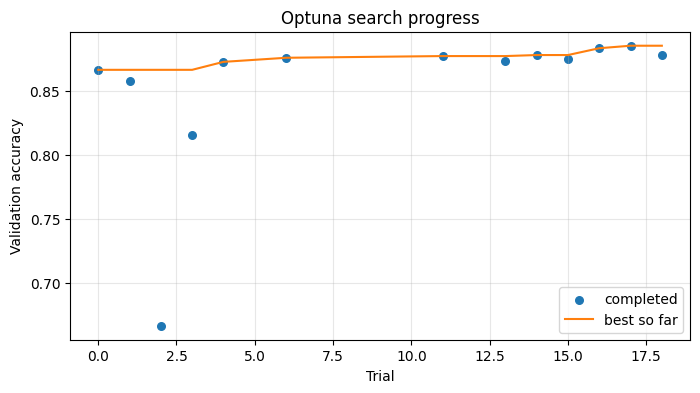

In [67]:
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"Completed: {len(completed)}, Pruned: {len(pruned)}")

plt.figure(figsize=(8, 4))
xs = [t.number for t in completed]
ys = [t.value for t in completed]
plt.scatter(xs, ys, s=30, label="completed")
if completed:
    best_so_far = np.maximum.accumulate(ys)
    plt.plot(xs, best_so_far, color="tab:orange", label="best so far")
plt.xlabel("Trial")
plt.ylabel("Validation accuracy")
plt.title("Optuna search progress")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Final training

Retrain from scratch with the best hyperparameters and keep the best-val-acc `state_dict`.

In [68]:
FINAL_EPOCHS = 60

best_params = study.best_params
print("Retraining with:", best_params)

model = RecognitionCNN(
    conv1_ch=best_params["conv1_ch"],
    conv2_ch=best_params["conv2_ch"],
    fc_dim=best_params["fc_dim"],
    dropout=best_params["dropout"],
).to(device)
optimizer = build_optimizer(
    best_params["optimizer"], model.parameters(), best_params["lr"]
)
scheduler = build_scheduler(
    best_params["scheduler"], optimizer, total_epochs=FINAL_EPOCHS
)
criterion = nn.CrossEntropyLoss(
    weight=class_weights, label_smoothing=best_params["label_smoothing"]
)

train_loader, val_loader = make_loaders(best_params["batch_size"], tuning=False)
test_loader = DataLoader(
    test_set, batch_size=512, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []
learning_rates: list[float] = []
best_val_acc = 0.0
best_state: dict | None = None

pbar = tqdm(range(1, FINAL_EPOCHS + 1), desc="Training")
for epoch in pbar:
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    tr_loss, tr_acc = execute_trainstep(
        model, device, train_loader, criterion, optimizer
    )
    va_loss, va_acc = validate(model, device, val_loader, criterion)
    if scheduler is not None:
        scheduler.step()

    train_losses.append(tr_loss)
    valid_losses.append(va_loss)
    train_accs.append(tr_acc)
    valid_accs.append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = copy.deepcopy(model.state_dict())

    pbar.set_postfix(
        lr=f"{current_lr:.2e}",
        train_loss=f"{tr_loss:.4f}", val_loss=f"{va_loss:.4f}",
        train_acc=f"{tr_acc:.4f}", val_acc=f"{va_acc:.4f}",
    )

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Retraining with: {'lr': 0.006772726635652365, 'batch_size': 64, 'optimizer': 'adamw', 'scheduler': 'cosine', 'dropout': 0.10289270564672033, 'label_smoothing': 0.05, 'conv1_ch': 48, 'conv2_ch': 32, 'fc_dim': 256}


Training: 100%|██████████| 60/60 [53:39<00:00, 53.65s/it, lr=5.64e-06, train_acc=0.9133, train_loss=0.6334, val_acc=0.9096, val_loss=0.6209] 


Best validation accuracy: 0.9106


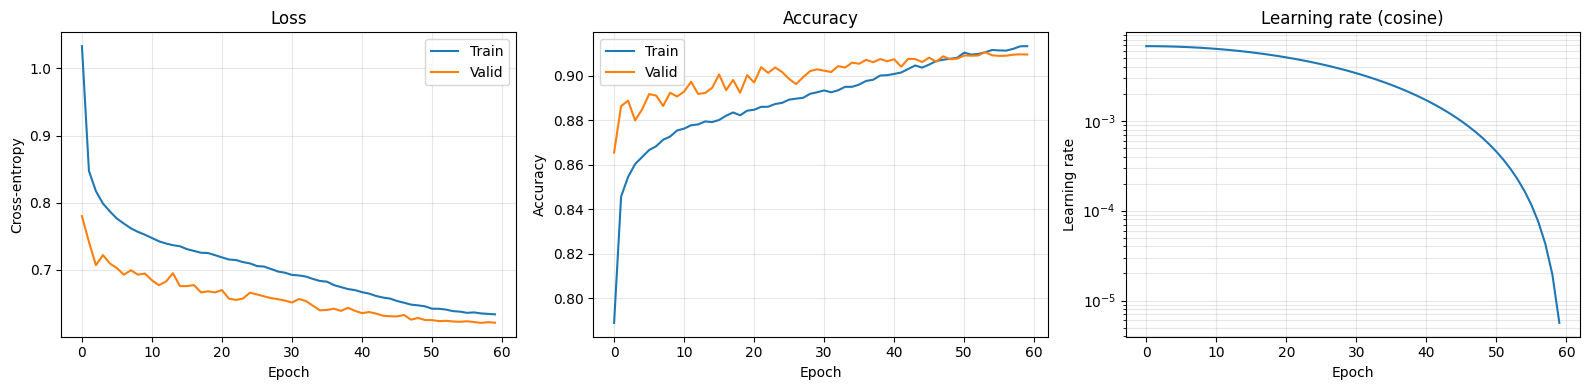

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_losses, label="Train")
axes[0].plot(valid_losses, label="Valid")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label="Train")
axes[1].plot(valid_accs, label="Valid")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(learning_rates)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning rate")
axes[2].set_title(f"Learning rate ({best_params['scheduler']})")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Test evaluation

In [76]:
assert best_state is not None, "Expected best_state to be populated during training"
model.load_state_dict(best_state)

y_pred, y_true = evaluate_predictions(model, device, test_loader)
test_acc = float((y_pred == y_true).mean())
print(f"Test accuracy: {test_acc:.4f}")

/Users/suryaguthikonda/Personal/Github/crisp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.9057


### Classification report

Digits + the 10 worst-performing letter classes.

In [77]:
full_report = classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=LABEL_MAP,
    zero_division=0,
    output_dict=True,
)

per_class_f1 = [(i, full_report[LABEL_MAP[i]]["f1-score"]) for i in range(NUM_CLASSES)]
digit_indices = list(range(10))
non_digit_sorted = sorted(
    ((i, f1) for i, f1 in per_class_f1 if i >= 10), key=lambda t: t[1]
)
worst_non_digits = [i for i, _ in non_digit_sorted[:10]]
selected = digit_indices + worst_non_digits

print(classification_report(
    y_true, y_pred,
    labels=selected,
    target_names=[LABEL_MAP[i] for i in selected],
    zero_division=0,
    digits=4,
))
print(f"Macro F1 (all {NUM_CLASSES} classes): {full_report['macro avg']['f1-score']:.4f}")
print(f"Weighted F1              : {full_report['weighted avg']['f1-score']:.4f}")

              precision    recall  f1-score   support

           0     0.6550    0.7500    0.6993       400
           1     0.5755    0.7050    0.6337       400
           2     0.9160    0.9275    0.9217       400
           3     0.9975    0.9900    0.9937       400
           4     0.9772    0.9625    0.9698       400
           5     0.9603    0.9075    0.9332       400
           6     0.9670    0.9525    0.9597       400
           7     0.9732    0.9975    0.9852       400
           8     0.9627    0.9675    0.9651       400
           9     0.7214    0.8675    0.7877       400
           L     0.7026    0.4725    0.5650       400
           O     0.7184    0.6250    0.6684       400
           f     0.6995    0.6575    0.6778       400
           I     0.6500    0.7150    0.6810       400
           q     0.7806    0.6225    0.6926       400
           F     0.7068    0.7050    0.7059       400
           g     0.7913    0.7300    0.7594       400
           Z     0.9342    

### Confusion matrix

Row-normalized, log-scaled so off-diagonal entries stay visible.

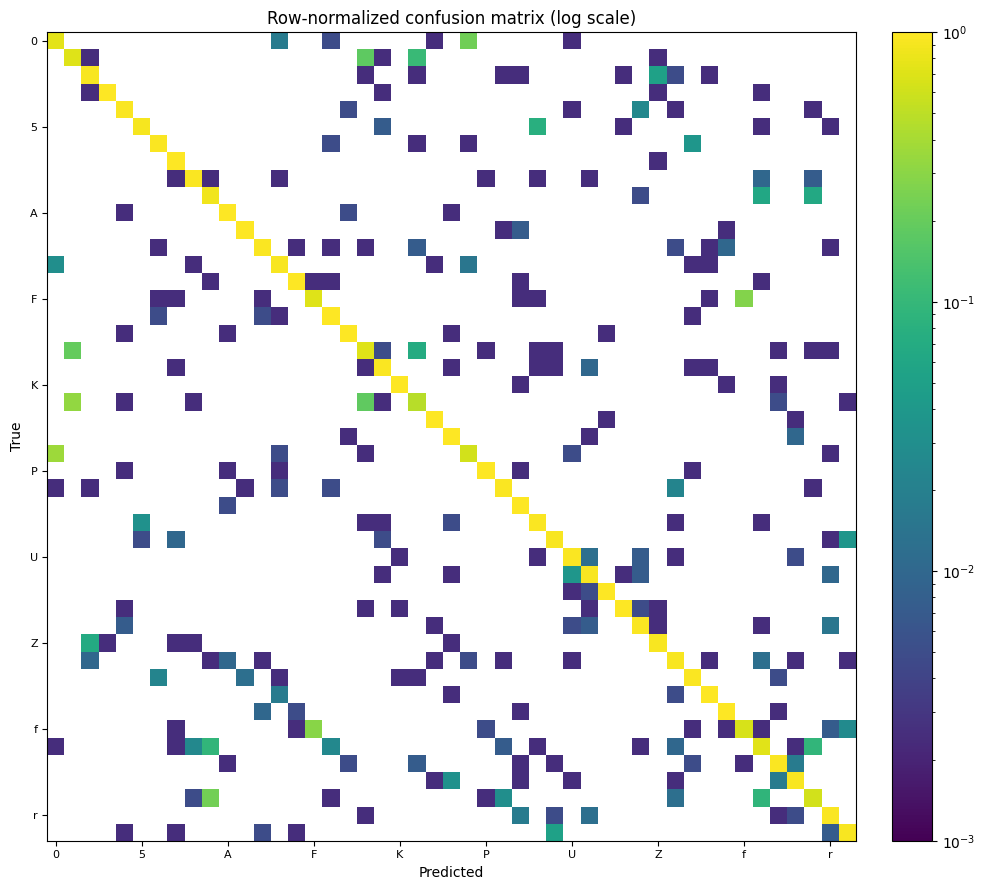

Top off-diagonal confusions (row -> col, fraction of row):
   O -> 0 : 0.360
   L -> 1 : 0.325
   f -> F : 0.290
   F -> f : 0.280
   q -> 9 : 0.233
   0 -> O : 0.223
   I -> 1 : 0.195
   L -> I : 0.188
   1 -> I : 0.180
   1 -> L : 0.107


In [78]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm_norm, cmap="viridis", norm=plt.matplotlib.colors.LogNorm(vmin=1e-3, vmax=1.0))
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Row-normalized confusion matrix (log scale)")
step = 5
ax.set_xticks(range(0, NUM_CLASSES, step))
ax.set_xticklabels([LABEL_MAP[i] for i in range(0, NUM_CLASSES, step)], fontsize=8)
ax.set_yticks(range(0, NUM_CLASSES, step))
ax.set_yticklabels([LABEL_MAP[i] for i in range(0, NUM_CLASSES, step)], fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

off_diag = cm_norm.copy()
np.fill_diagonal(off_diag, 0)
flat = np.argsort(off_diag.flatten())[::-1][:10]
print("Top off-diagonal confusions (row -> col, fraction of row):")
for idx in flat:
    r, c = divmod(int(idx), NUM_CLASSES)
    print(f"  {LABEL_MAP[r]:>2} -> {LABEL_MAP[c]:<2}: {off_diag[r, c]:.3f}")

### Sample predictions

16 random test samples (`pred / true`, green = correct).

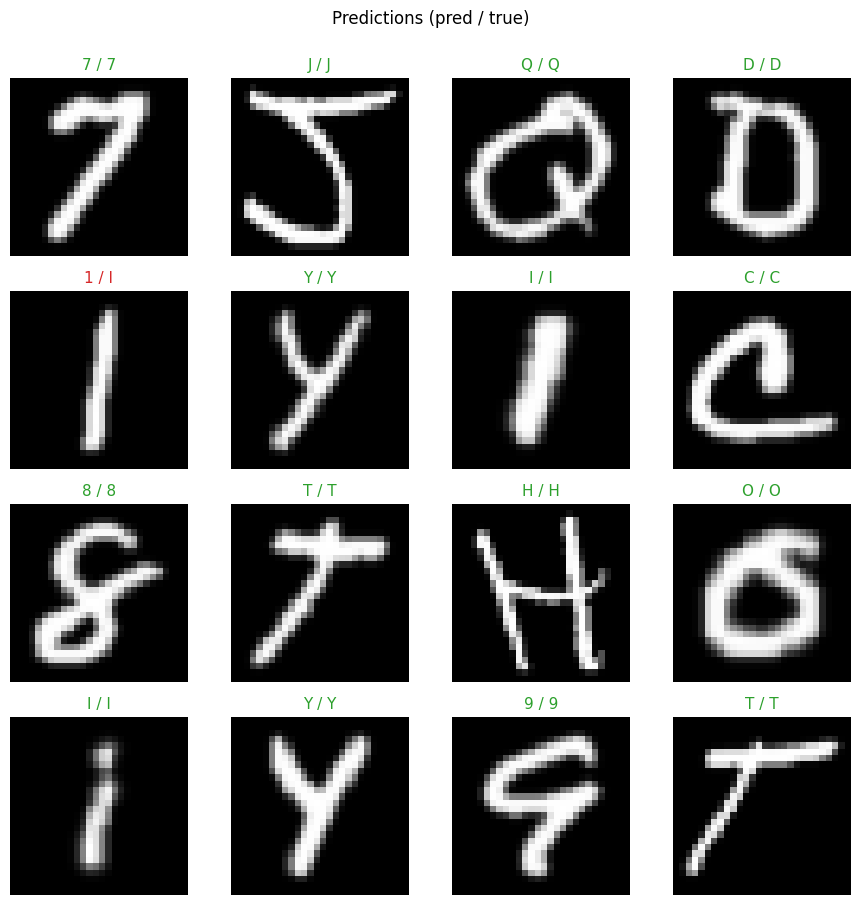

In [79]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(test_set), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for ax, idx in zip(axes.flatten(), sample_indices):
    img_tensor, label = test_set[int(idx)]
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
        pred = int(logits.argmax(dim=1).item())
    correct = pred == label
    img = img_tensor.squeeze().cpu().numpy()
    img = img * EMNIST_STD[0] + EMNIST_MEAN[0]
    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"{LABEL_MAP[pred]} / {LABEL_MAP[label]}",
        color=("tab:green" if correct else "tab:red"),
        fontsize=11,
    )
    ax.axis("off")
plt.suptitle("Predictions (pred / true)", y=1.0)
plt.tight_layout()
plt.show()

## Save weights

Save state dict + hyperparameters + label map so `../main.py` can rebuild the model.

In [80]:
weights_path = MODELS_DIR / "recognition_cnn.pt"
torch.save(
    {
        "model_state_dict": best_state,
        "best_params": best_params,
        "num_classes": NUM_CLASSES,
        "label_map": LABEL_MAP,
        "img_size": IMG_SIZE,
        "mean": EMNIST_MEAN,
        "std": EMNIST_STD,
        "val_accuracy": best_val_acc,
        "test_accuracy": test_acc,
    },
    weights_path,
)
print("Saved weights to:", weights_path)

Saved weights to: /Users/suryaguthikonda/Personal/Github/crisp/stage1_ocr/models/recognition_cnn.pt


## Notes

To use this with the segmentation output, crops must be grayscale (dark ink on light background), padded square, resized to 28x28, then run through `eval_transform`. Predictions go back to characters via `LABEL_MAP`.

Most remaining errors are classic OCR lookalikes (`0`/`O`, `1`/`l`/`I`, `q`/`g`, `B`/`8`). To improve further: more aggressive augmentation (cutout, elastic), longer training, or switch to `byclass` if case sensitivity is needed.